In [33]:
#Imports
import pandas as pd
import numpy as np
import glob 
import seaborn as sns
import matplotlib.pyplot as plt

In [34]:
#Load and check files
files = glob.glob("CRMLSSold/*.csv")
files

print(f"Found {len(files)} files:")
files


Found 9 files:


['CRMLSSold\\CRMLSSold202510.csv',
 'CRMLSSold\\CRMLSSold202511.csv',
 'CRMLSSold\\CRMLSSold202512.csv',
 'CRMLSSold\\CRMLSSold202601.csv',
 'CRMLSSold\\CRMLSSold202602.csv',
 'CRMLSSold\\CRMLSSold202603.csv',
 'CRMLSSold\\CRMLSSold202604.csv',
 'CRMLSSold\\CRMLSSold202605.csv',
 'CRMLSSold\\CRMLSSold202606.csv']

In [35]:
df = pd.concat([pd.read_csv(f, low_memory=False) for f in files], ignore_index=True)

print("Raw shape:", df.shape)
df.head()

Raw shape: (191232, 78)


,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,...,LotSizeDimensions,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict
0,NorthSanLuisObispo,NorthSanLuisObispo,NaN,NaN,NaN,NaN,NaN,NaN,479293596,newlin@pacificaCRE.com,...,NaN,1807.0,NaN,NaN,NaN,NaN,93446,NaN,1807.0,NaN
1,TheInlandGateway,TheInlandGateway,NaN,True,NaN,NaN,NaN,12000.0,446914808,nleimers@hotmail.com,...,NaN,14253.0,NaN,False,NaN,NaN,92325,0.0,14253.0,NaN
2,SanDiego,SanDiego,Wood,True,NaN,NaN,False,1695.0,445176588,mannybehar@yahoo.com,...,NaN,NaN,NaN,NaN,0.0,NaN,92126,0.0,NaN,NaN
3,SanDiego,SanDiego,NaN,False,NaN,NaN,False,950000.0,1145282039,chase@cromwellhomegroup.com,...,NaN,NaN,NaN,False,2.0,NaN,91901,NaN,NaN,NaN
4,SanDiego,SanDiego,NaN,False,NaN,NaN,False,970000.0,1145278097,rory@corneliusestates.net,...,NaN,NaN,NaN,False,2.0,NaN,92115,NaN,NaN,NaN


In [36]:
#Restrict to reisdential and single family
df = df[
    (df["PropertyType"] == "Residential") &
    (df["PropertySubType"] == "SingleFamilyResidence")
]

print("Filtered shape:", df.shape)




Filtered shape: (96353, 78)


In [37]:
eda_cols = [
    "ClosePrice",
    "LivingArea",
    "BedroomsTotal",
    "BathroomsTotalInteger",
    "LotSizeSquareFeet"
]

eda = df[eda_cols].copy()
eda.describe()

,ClosePrice,LivingArea,BedroomsTotal,BathroomsTotalInteger,LotSizeSquareFeet
count,9.635300e+04,96308.000000,96353.000000,96352.000000,9.469800e+04
mean,1.334616e+06,2056.632823,3.499040,2.643609,4.551789e+05
std,7.156413e+06,1042.572928,0.964477,1.129753,1.946460e+07
min,1.750000e+00,0.000000,0.000000,0.000000,0.000000e+00
25%,6.239000e+05,1390.000000,3.000000,2.000000,5.663000e+03
50%,8.949500e+05,1827.000000,3.000000,2.000000,7.273000e+03
75%,1.425000e+06,2453.000000,4.000000,3.000000,1.045400e+04
max,9.895000e+08,31068.000000,22.000000,23.000000,1.938943e+09


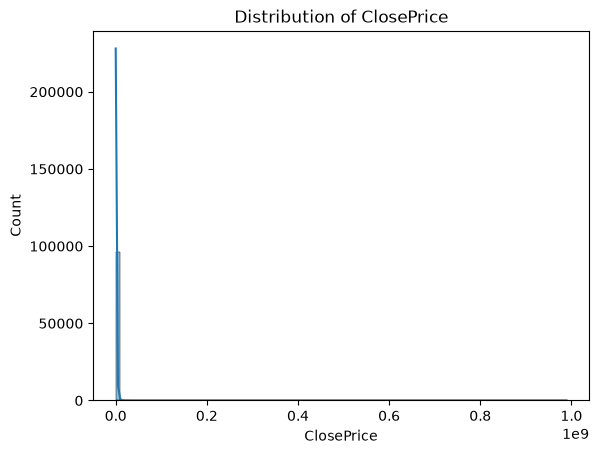

In [38]:
plt.figure()
sns.histplot(eda["ClosePrice"], kde=True, bins=100)
plt.title("Distribution of ClosePrice")
plt.xlabel("ClosePrice")
plt.show()


In [39]:
df["ClosePrice"].describe()


count    9.635300e+04
mean     1.334616e+06
std      7.156413e+06
min      1.750000e+00
25%      6.239000e+05
50%      8.949500e+05
75%      1.425000e+06
max      9.895000e+08
Name: ClosePrice, dtype: float64

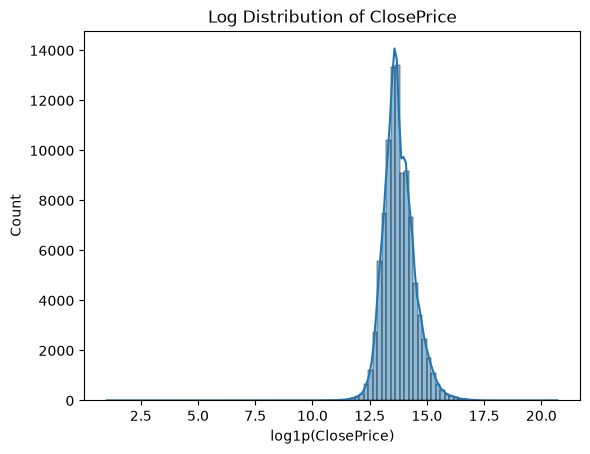

In [40]:
sns.histplot(np.log1p(df["ClosePrice"]), kde=True, bins=100)
plt.title("Log Distribution of ClosePrice")
plt.xlabel("log1p(ClosePrice)")
plt.show()


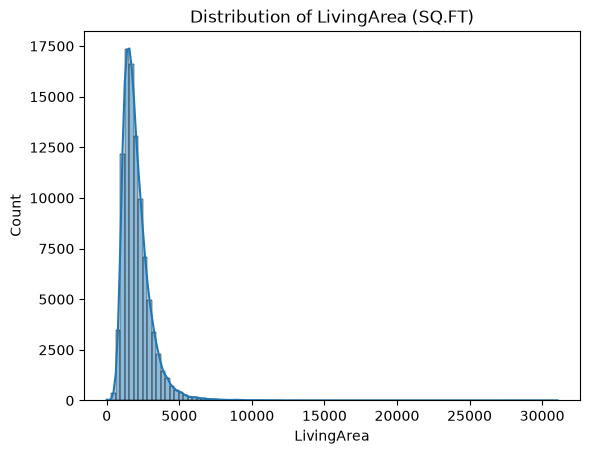

In [41]:
#living area
plt.figure()
sns.histplot(eda["LivingArea"], kde=True, bins=100)
plt.title("Distribution of LivingArea (SQ.FT)")
plt.xlabel("LivingArea")
plt.show()

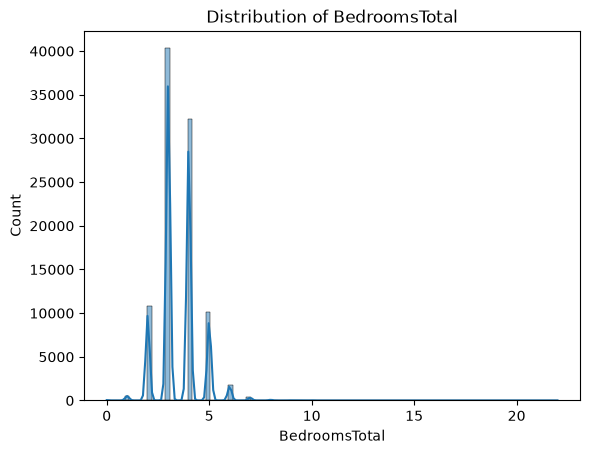

In [42]:
#bedrooms
plt.figure()
sns.histplot(eda["BedroomsTotal"], kde=True, bins=100)
plt.title("Distribution of BedroomsTotal")
plt.xlabel("BedroomsTotal")
plt.show()

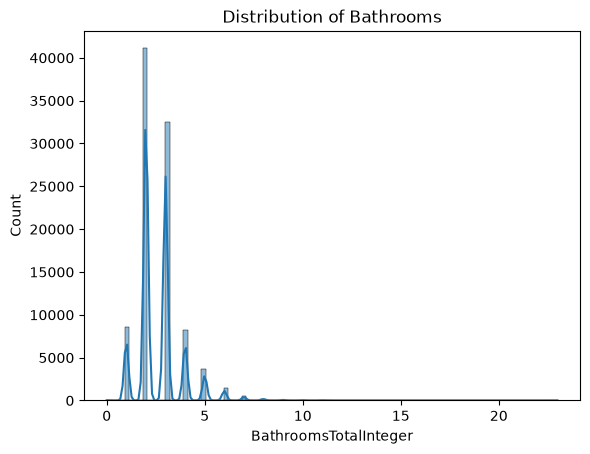

In [43]:
#bathrooms
plt.figure()
sns.histplot(eda["BathroomsTotalInteger"], kde=True, bins=100)
plt.title("Distribution of Bathrooms")
plt.xlabel("BathroomsTotalInteger")
plt.show()

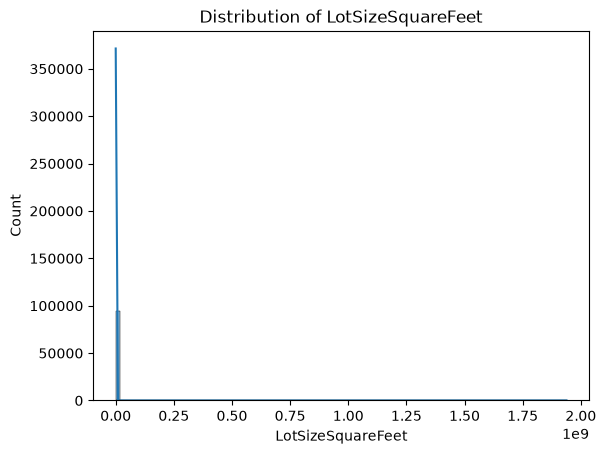

In [44]:
#lot size
plt.figure()
sns.histplot(eda["LotSizeSquareFeet"], kde=True, bins=100)
plt.title("Distribution of LotSizeSquareFeet")
plt.xlabel("LotSizeSquareFeet")
plt.show()

In [45]:
df["LotSizeSquareFeet"].describe()

count    9.469800e+04
mean     4.551789e+05
std      1.946460e+07
min      0.000000e+00
25%      5.663000e+03
50%      7.273000e+03
75%      1.045400e+04
max      1.938943e+09
Name: LotSizeSquareFeet, dtype: float64

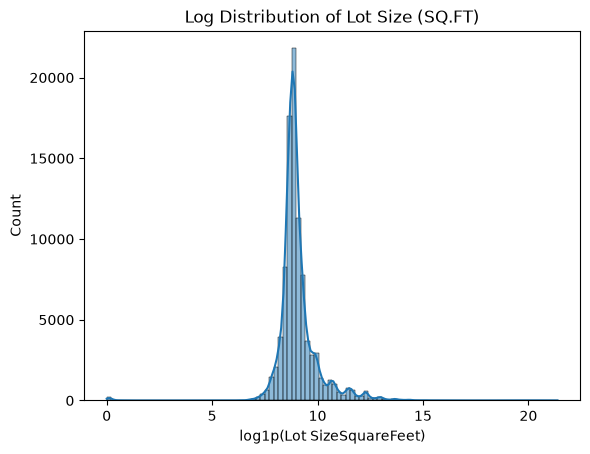

In [46]:
sns.histplot(np.log1p(df["LotSizeSquareFeet"]), kde=True, bins=100)
plt.title("Log Distribution of Lot Size (SQ.FT)")
plt.xlabel("log1p(Lot SizeSquareFeet)")
plt.show()


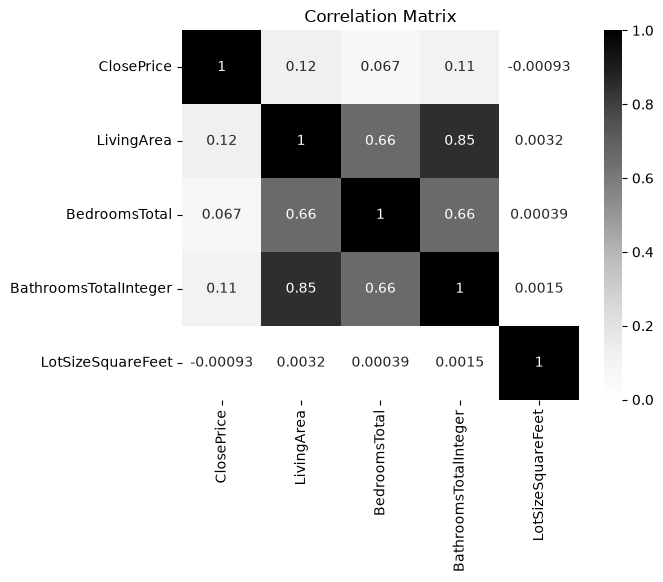

In [47]:
plt.figure()
sns.heatmap(eda.corr(numeric_only=True), annot=True, cmap="Grays")
plt.title("Correlation Matrix")
plt.show()


In [48]:
df.to_csv("filtered_crmls.csv", index=False)